In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay,
                             precision_recall_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/rapido_project/data/captain_synthetic.csv')

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['is_churned'].mean():.2%}")

Mounted at /content/drive
Shape: (10000, 24)
Churn rate: 41.06%


In [18]:
df['is_bike'] = (df['vehicle_type'] == 'bike').astype(int)
df['is_parttime'] = (df['captain_type'] == 'parttime').astype(int)
df['is_bengaluru'] = (df['city'] == 'Bengaluru').astype(int)
df['rides_decay_x_parttime'] = df['ride_decay_rate'] * df['is_parttime']
df['low_earnings_x_bike'] = df['estimated_daily_earnings'] * df['is_bike']
df['cancellation_x_zone'] = df['cancellation_rate'] * df['zone_switches']
df['week4_x_incentive'] = df['rides_week4'] * df['incentive_claimed']

drop_cols = [
    'captain_id',
    'city',
    'vehicle_type',
    'captain_type',
    'payment_method_pref',
    'signup_month',
    'is_churned',
    'churn_probability',
    'risk_segment'
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['is_churned']

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"Class balance:\n{y.value_counts(normalize=True).round(2)}")

Features: ['rides_week1', 'rides_week2', 'rides_week3', 'rides_week4', 'ride_decay_rate', 'night_rides_ratio', 'peak_hour_ratio', 'cancellation_rate', 'avg_ride_duration', 'avg_fare_per_km', 'petrol_cost_sensitivity', 'estimated_daily_earnings', 'zone_switches', 'incentive_claimed', 'streak_completed', 'app_opens_per_day', 'support_tickets', 'is_bike', 'is_parttime', 'is_bengaluru', 'rides_decay_x_parttime', 'low_earnings_x_bike', 'cancellation_x_zone', 'week4_x_incentive']
X shape: (10000, 24)
Class balance:
is_churned
0    0.59
1    0.41
Name: proportion, dtype: float64


In [19]:

X_train = X.iloc[:8000]
X_test  = X.iloc[8000:]
y_train = y.iloc[:8000]
y_test  = y.iloc[8000:]

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")

Train size: (8000, 24)
Test size:  (2000, 24)
Train churn rate: 41.21%
Test churn rate:  40.45%


In [20]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 4703, 1: 3297}
After SMOTE:  {1: 4703, 0: 4703}


In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_sm, y_train_sm)

print("All 3 models trained")

All 3 models trained


In [22]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

print(f"{'Model':<25} {'ROC-AUC':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc   = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    prec  = report['1']['precision']
    rec   = report['1']['recall']
    f1    = report['1']['f1-score']

    results[name] = {'auc': auc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f"{name:<25} {auc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

Model                        ROC-AUC  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression            0.739      0.589      0.701      0.640
Random Forest                  0.740      0.608      0.663      0.634
XGBoost                        0.733      0.594      0.663      0.626


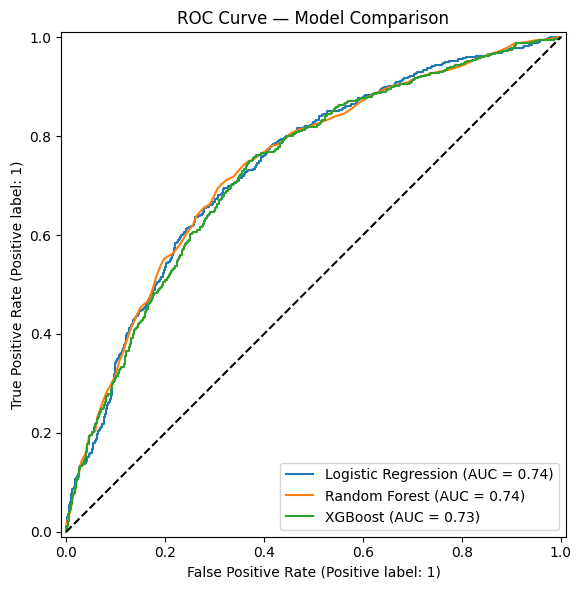

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.set_title('ROC Curve — Model Comparison')
ax.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.tight_layout()
plt.show()

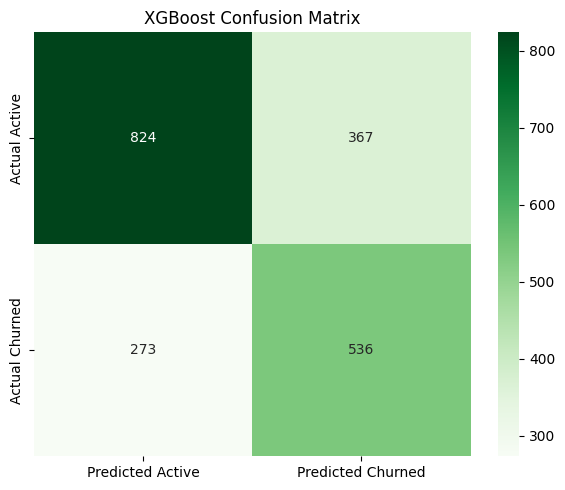


True Positives  (correctly caught churners): 536
False Positives (wrongly flagged active):    367
False Negatives (missed churners):           273
True Negatives  (correctly kept active):     824

Of every 100 churners, model catches: 66


In [24]:
y_pred_xgb = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted Active', 'Predicted Churned'],
    yticklabels=['Actual Active', 'Actual Churned']
)
ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (correctly caught churners): {tp}")
print(f"False Positives (wrongly flagged active):    {fp}")
print(f"False Negatives (missed churners):           {fn}")
print(f"True Negatives  (correctly kept active):     {tn}")
print(f"\nOf every 100 churners, model catches: {tp/(tp+fn)*100:.0f}")

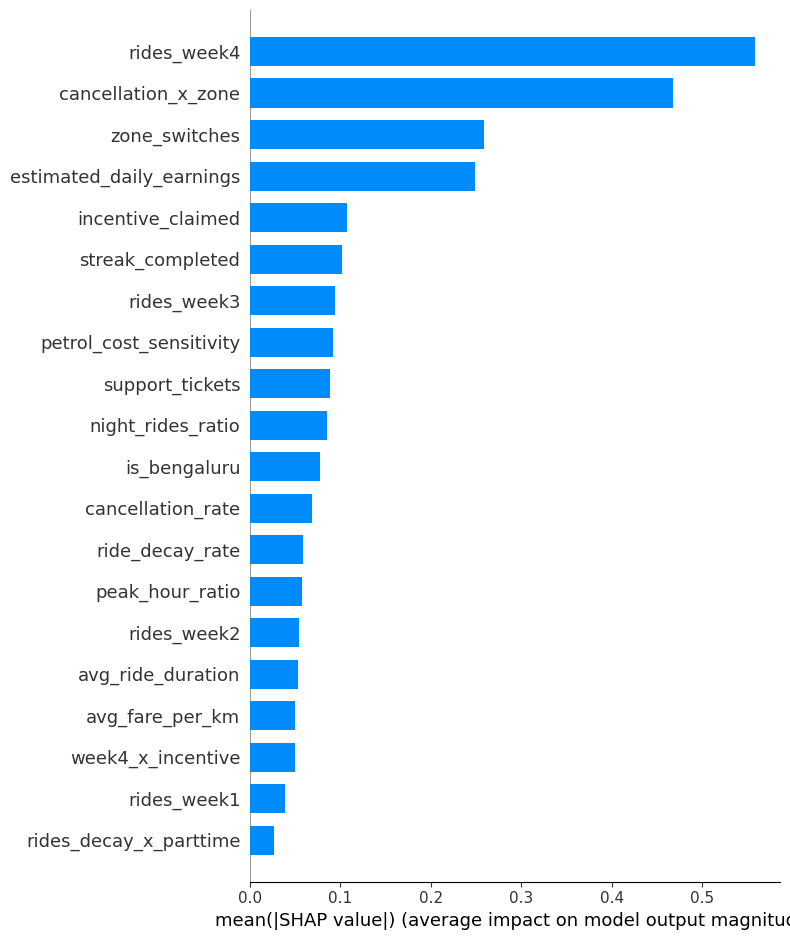

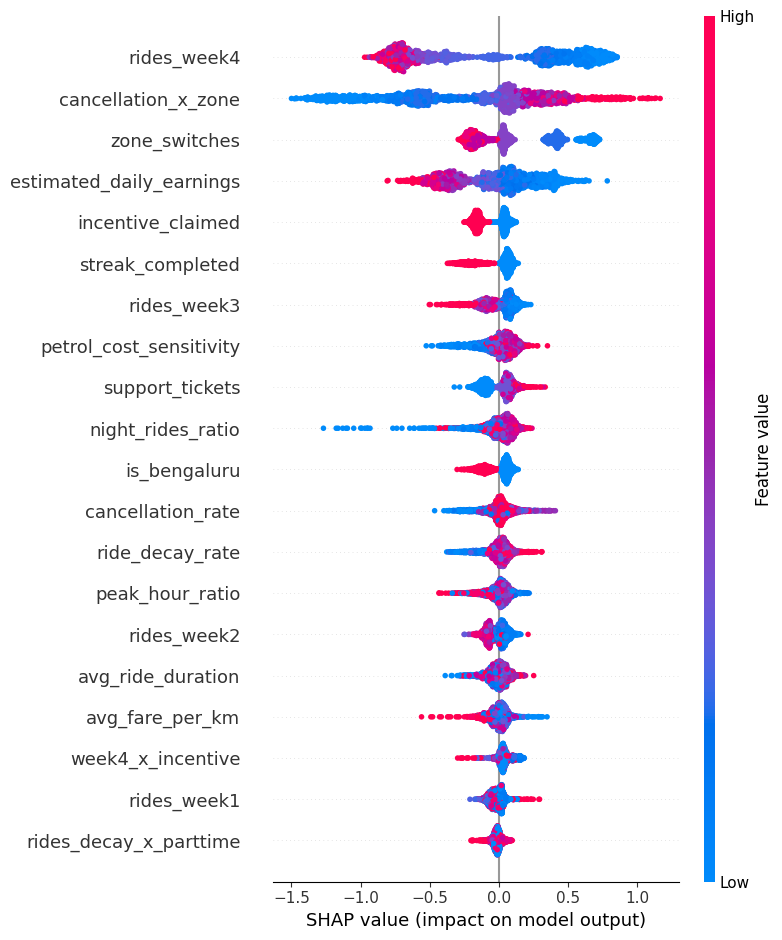

In [25]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    title='Feature Importance — What Drives Churn?'
)

plt.figure()
shap.summary_plot(shap_values, X_test)

In [11]:
df['churn_probability'] = xgb.predict_proba(X)[:, 1]

df['risk_segment'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.35, 0.65, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk Segment Distribution:")
print(df['risk_segment'].value_counts())
print("\nChurn rate by segment (validation):")
print(df.groupby('risk_segment')['is_churned'].mean().round(2))

print("\nTop 10 highest risk captains:")
print(df[['captain_id', 'city', 'vehicle_type', 'captain_type',
          'rides_week4', 'churn_probability', 'risk_segment']]
      .sort_values('churn_probability', ascending=False)
      .head(10)
      .to_string(index=False))

Risk Segment Distribution:
risk_segment
Low Risk       4013
High Risk      3007
Medium Risk    2980
Name: count, dtype: int64

Churn rate by segment (validation):
risk_segment
Low Risk       0.14
Medium Risk    0.44
High Risk      0.74
Name: is_churned, dtype: float64

Top 10 highest risk captains:
captain_id      city vehicle_type captain_type  rides_week4  churn_probability risk_segment
  CAP02059 Hyderabad         bike     parttime            5           0.944136    High Risk
  CAP04696 Hyderabad         bike     parttime            3           0.941938    High Risk
  CAP09474     Delhi         bike     parttime            2           0.939979    High Risk
  CAP02431      Pune         bike     parttime            5           0.932378    High Risk
  CAP03093      Pune         bike     parttime            2           0.931652    High Risk
  CAP08993 Hyderabad         bike     parttime            4           0.931407    High Risk
  CAP07738   Chennai         bike     parttime          

In [28]:
import joblib

joblib.dump(lr, '/content/drive/MyDrive/rapido_project/data/churn_model_final.pkl')

df['churn_probability'] = lr.predict_proba(X)[:, 1]

df['risk_segment'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.35, 0.65, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df.to_csv('/content/drive/MyDrive/rapido_project/data/captains_scored.csv', index=False)

print("Model saved: churn_model_final.pkl")
print("Scored dataset saved: captains_scored.csv")
print(f"\nFinal model AUC: {results['Logistic Regression']['auc']:.3f}")
print(f"\nRisk Segment Distribution:")
print(df['risk_segment'].value_counts())
print(f"\nChurn rate by segment:")
print(df.groupby('risk_segment')['is_churned'].mean().round(2))

Model saved: churn_model_final.pkl
Scored dataset saved: captains_scored.csv

Final model AUC: 0.739

Risk Segment Distribution:
risk_segment
Low Risk       3729
Medium Risk    3323
High Risk      2948
Name: count, dtype: int64

Churn rate by segment:
risk_segment
Low Risk       0.17
Medium Risk    0.43
High Risk      0.68
Name: is_churned, dtype: float64
